In [2]:
source('~/hanshu/lib.R')

In [3]:
scRNA = read_rds('../output/sce.anno.rds')

In [ ]:
scRNA = NormalizeData(scRNA)

In [4]:
color = c("#AB1197FF",
                "#E391BA",
                "#D4D98A",
                "#FF7F0EFF",
                "#EDC962",
                "#C5B0D5FF",
                #"#2BAE9E",
                "#215189")

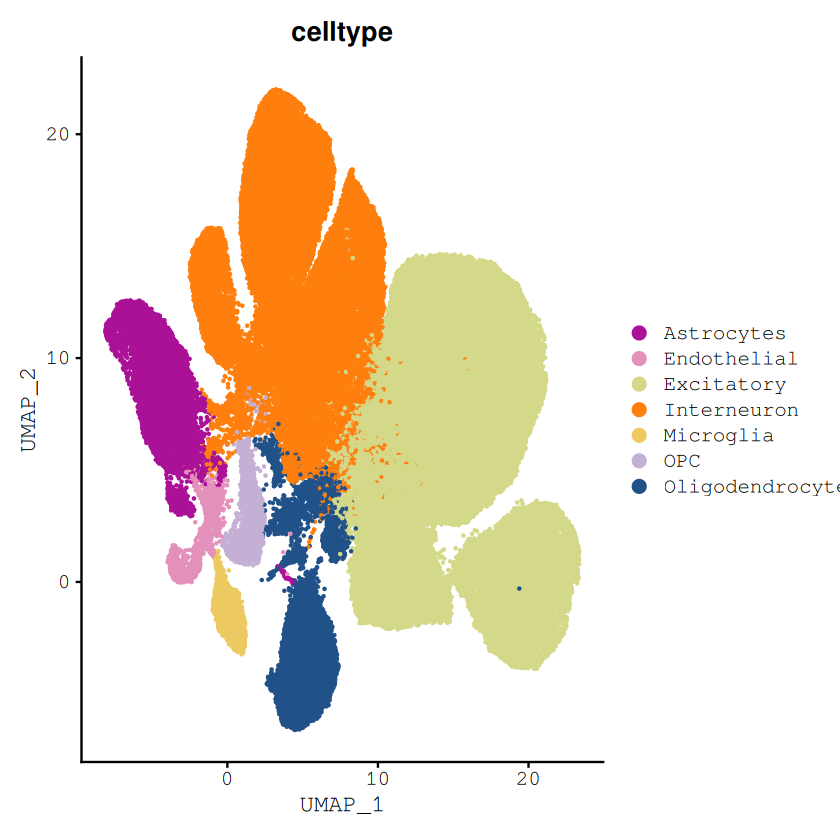

In [8]:
p1 = DimPlot(scRNA,group.by = 'celltype',raster=FALSE,cols = color)
p1

In [9]:
ggsave(p1,filename = '../figure/figure1/1.umap.R.pdf',create.dir = T)

✔ Created directory: ../figure/figure1.

Saving 7 x 7 in image


In [10]:
Idents(scRNA) = 'celltype'

In [12]:
source('~/hanshu/ks_scAverExp.R')
source('~/hanshu/ks_scDotplot.R')

In [13]:
table(scRNA$celltype)


      Astrocytes      Endothelial       Excitatory      Interneuron 
            9552             1752            70674            45415 
       Microglia              OPC Oligodendrocytes 
            1446             2713             9982 

In [14]:
featureSets <- list("Astrocytes" = c("Gja1", "Etnppl",  "Aqp4"),
                    "Endothelial" = c("Vwf",  "Epas1"),
                    "Excitatory" = c("Nell2", "Slc17a7", "Neurod6"),
                    "Interneuron" = c("Gad1", "Gad2", "Slc32a1"),
                    "Microglia" = c("Ptprc", "Apbb1ip", "P2ry12", "Cx3cr1",'Dock8'),
                    "OPC" = c("Vcan", "Pdgfra"),
                    "Oligodendrocytes" = c("Cldn11", "Mog", "Mbp")
                    #"Plasma" = c("MZB1", "XBP1", "JCHAIN"),
                    #"Proliferative" = c("MKI67", "BIRC5", "CDK1"),
                    #"T_cells" = c("PTPRC", "CD3D", "CD3E", "CD8A", "CD8B")
                    #"PN_RO" = c("IL1RAPL2", "POU6F2", "NRG1"),
                    #"LAMPs" = c("PRELID2", "TRPC3"),
                    #"Vas" = c("COL15A1","NPNT")
                    )

In [15]:
Idents(scRNA) = 'celltype'

In [17]:
scRNA = NormalizeData(scRNA)

In [18]:
set.seed(123)
scRNA_sub = subset(scRNA,downsample = 1000)
scRNA_sub$celltype = as.character(scRNA_sub$celltype)

In [19]:
#分析作图分为两步，首先我们计算矩阵
Exp_scRNA <- ks_scAverExp(obj = scRNA_sub,#构建好的seurat object
                          features = featureSets, #上面的marker基因list
                          CellTypes = unique(scRNA_sub$celltype))#celltype名称，也可以是自行输入向量

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 1.4 GiB”


In [20]:
library(dittoSeq)

In [21]:
ks_scDotplot <- function(
    obj,
    features,
    CellTypes,
    avgPctMat,
    aspectRatio = NULL,
    colorSet = FALSE,
    gradientColor = NULL,
    sizeLims = NULL,
    pal
){
  
  suppressPackageStartupMessages({
    library(ggplot2)
    library(RColorBrewer)
  })
  
  #========================
  # object type
  #========================
  dataType <- class(obj)[1]
  
  #========================
  # feature order
  #========================
  feature_ord <- unique(unlist(features))
  feature_ord <- rev(feature_ord)
  
  #========================
  # group order
  #========================
  if(!is.null(names(features))){
    group_ord <- unique(names(features))
  } else {
    group_ord <- unique(CellTypes)
  }
  
  #========================
  # factor order
  #========================
  avgPctMat$feature <- factor(
    avgPctMat$feature,
    levels = feature_ord
  )
  
  avgPctMat$group <- factor(
    avgPctMat$group,
    levels = group_ord
  )
  
  #========================
  # aspect ratio
  #========================
  if(is.null(aspectRatio)){
    
    aspectRatio <- length(feature_ord) /
      length(group_ord)
  }
  
  #========================
  # remove NA
  #========================
  avgPctMat <- avgPctMat[
    !is.na(avgPctMat$avgExpr) &
      !is.na(avgPctMat$pctExpr),
  ]
  
  #========================
  # avoid all-zero size
  #========================
  avgPctMat$plotPct <- pmax(
    avgPctMat$pctExpr,
    0.01
  )
  
  #========================
  # base plot
  #========================
  p <- ggplot(
    avgPctMat,
    aes(
      x = group,
      y = feature,
      color = avgExpr,
      size = plotPct
    )
  ) +
    geom_point() +
    xlab("") +
    ylab("") +
    theme_bw() +
    theme(
      panel.grid.major = element_blank(),
      panel.grid.minor = element_blank(),
      
      aspect.ratio = aspectRatio,
      
      axis.text.x = element_text(
        angle = 90,
        hjust = 1,
        vjust = 0.5,
        color = "black"
      ),
      
      axis.text.y = element_text(
        face = "italic",
        color = "black"
      ),
      
      panel.border = element_rect(
        fill = NA,
        color = "black",
        linewidth = 0.7
      ),
      
      legend.key = element_blank(),
      
      legend.title = element_text(
        size = 10
      ),
      
      legend.text = element_text(
        size = 8
      )
    ) +
    coord_cartesian(clip = "off")
  
  #========================
  # size scale
  #========================
  if(!is.null(sizeLims)){
    
    p <- p +
      scale_size_continuous(
        limits = sizeLims
      )
  }
  
  #========================
  # legend title
  #========================
  if(dataType == "Seurat"){
    
    names_title <- "Relative\nExpression"
    
  } else {
    
    names_title <- "Relative\ngene activity"
  }
  
  #========================
  # color scale
  #========================
  if(colorSet == FALSE){
    
    p <- p +
      scale_color_gradientn(
        colours = rev(
          brewer.pal(
            n = 10,
            name = "RdBu"
          )
        ),
        name = names_title
      )
    
  } else {
    
    p <- p +
      scale_color_gradientn(
        colours = gradientColor,
        name = names_title
      )
  }
  
  #========================
  # size legend
  #========================
  p <- p +
    guides(
      size = guide_legend(
        title = "Percentage\nExpressed"
      )
    )
  
  #========================
  # annotation color bar
  #========================
  if(length(pal) < length(group_ord)){
    
    pal <- rep(
      pal,
      length.out = length(group_ord)
    )
  }
  
  anno_df <- data.frame(
    x = seq_along(group_ord),
    y = rep(
      length(feature_ord) + 0.8,
      length(group_ord)
    ),
    col = pal[seq_along(group_ord)]
  )
  
  p <- p +
    geom_point(
      data = anno_df,
      aes(x = x, y = y),
      color = anno_df$col,
      size = 3,
      inherit.aes = FALSE
    )
  
  return(p)
}

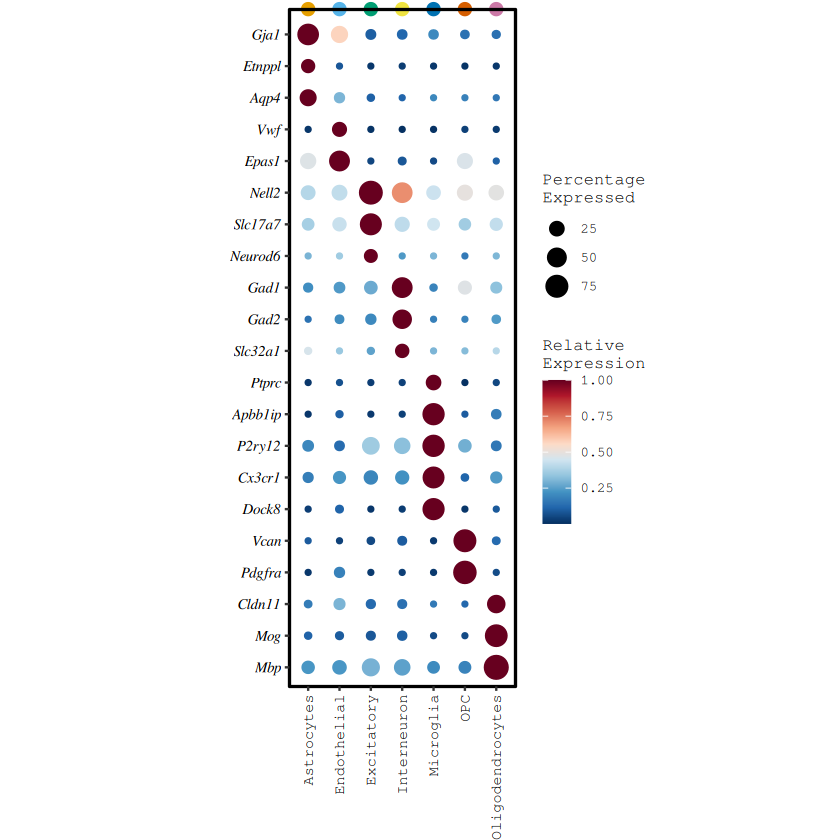

In [22]:
scRNA_dotplot <- ks_scDotplot(
    obj = scRNA_sub,
    features = featureSets,
    CellTypes = unique(scRNA_sub$celltype),
    avgPctMat = Exp_scRNA,
    pal = dittoSeq::dittoColors()
)

scRNA_dotplot

In [23]:
pdf('../figure/figure1/2.marker.pdf',width = 5,height = 6)
scRNA_dotplot
dev.off()

pdf 
  2

In [24]:
Idents(scRNA) = 'celltype'

In [25]:
library(future)

plan("multicore", workers = 32)

# 2. 修改全局设置：允许 Seurat 处理大型矩阵（防止报错：Total size of global objects...）
# 将内存限制增加到 100GB (100 * 1024^3)
options(future.globals.maxSize = 200 * 1024^3)

In [40]:
df_markers <- FindAllMarkers(scRNA, logfc.threshold = 0.25, min.diff.pct = 0.25, only.pos = T)

Calculating cluster Astrocytes



Calculating cluster Endothelial

Calculating cluster Excitatory

Calculating cluster Interneuron

Calculating cluster Microglia

Calculating cluster OPC

Calculating cluster Oligodendrocytes



In [48]:
df_markers <- df_markers[!grepl("^Gm|Rik$", rownames(df_markers)), ]

In [49]:
deg = df_markers
trna = scRNA

In [50]:
table(scRNA$celltype)


      Astrocytes      Endothelial       Excitatory      Interneuron 
            9552             1752            70674            45415 
       Microglia              OPC Oligodendrocytes 
            1446             2713             9982 

In [51]:
#01 差异基因计算-----------------------------------------------------
deg <- deg[deg$p_val_adj<0.05,]
top5_genes <- deg %>%
  group_by(cluster) %>% #按cluster列分组
  top_n(n = 5, wt = avg_log2FC) %>%  #根据avg_log2FC每个cluster取前5个
  ungroup() %>%
  mutate(cluster = factor(cluster, levels = c('Astrocytes','Endothelial','Excitatory','Interneuron',
  'Microglia','OPC','Oligodendrocytes'))) %>% #将cluster转化为因子
  arrange(cluster)
  
#02 提取top5_genes，计算每个 Cluster 的平均表达量---------------------
avg_exp_obj <- AverageExpression(trna, features = unique(top5_genes$gene), 
                                 group.by = "celltype", 
                                 assays = "RNA", 
                                 slot = "data")
plot_matrix_raw <- avg_exp_obj$RNA
plot_matrix_raw[1:4,1:4]

,Astrocytes,Endothelial,Excitatory,Interneuron
Gpc5,46.55369,2.442872,1.000678,1.440651
Slc1a2,84.02554,9.190438,4.798516,2.905882
Atp1a2,31.30752,27.585168,0.598117,1.044022
Apoe,85.63695,30.415674,2.918858,5.107562


In [52]:
#03 进行 Z-score 标准化 (按行/基因)--------------------------------
plot_matrix <- t(scale(t(plot_matrix_raw)))
# 极值修剪 (限制在 -2.5 到 2.5，防止颜色过爆)
limit <- 2.5
plot_matrix[plot_matrix > limit] <- limit
plot_matrix[plot_matrix < -limit] <- -limit


In [53]:
group_info <- colnames(plot_matrix)
# 确保顺序是按照 0, 1, 2... 排列的 (有时候 R 会变成 0, 1, 10, 11...)
cluster_levels <- levels(top5_genes$cluster)
plot_matrix <- plot_matrix[, cluster_levels] # 重新排序列
group_info <- factor(colnames(plot_matrix), levels = cluster_levels)
#05. 准备 highlight_list (高亮名单) -------------------------------
gene_ordering <- top5_genes %>%
  mutate(cluster = factor(cluster, levels = levels(group_info))) %>% # 确保因子顺序 0,1,2...
  arrange(cluster) %>%           # 严格按 Cluster 排序
  distinct(gene, .keep_all = T)  # 
plot_matrix <- plot_matrix[gene_ordering$gene, ]
highlight_list <- top5_genes$gene #可以调整展示

In [54]:
library(RColorBrewer)
library(circlize)
library(ComplexHeatmap)
library(grid)
# --- A. 复刻 scPalette 函数 (用于顶部 Cluster 色条) ---------------
scPalette <- function(n) {
  # 这是 Figure 1E 源码里指定的经典 26 色
  colorSpace <- c('#c74619', '#82bbc2', '#94c58f', '#4b6b83', '#d18678', '#72778A', '#67896c', '#504b83',
'#4b6aa8','#bc9a7f')
  if (n <= length(colorSpace)) {
    colors <- colorSpace[1:n]
  } else {
    colors <- colorRampPalette(colorSpace)(n)
  }
  return(colors)
}
# 生成 Cluster 颜色
n_clusters <- length(levels(group_info))
cluster_colors <- scPalette(n_clusters)
names(cluster_colors) <- levels(group_info)
# --- B. 复刻热图主体配色 (RdBu 反转) ------------------------------
# 源码逻辑：取9级 RdBu，反转(红高蓝低)，然后插值成100个颜色
col.heat <- colorRampPalette(rev(brewer.pal(n = 9, name = "RdBu")))
cols <- col.heat(100)
# 对应数值范围 -2.5 到 2.5
breaks <- seq(-2.5, 2.5, length = 100)
col_fun <- colorRamp2(breaks, cols) # 生成颜色映射函数
# --- C. 构建顶部注释 (Top Annotation) -----------------------------
top_ha <- HeatmapAnnotation(
  Cluster = group_info,
  col = list(Cluster = cluster_colors), # 使用 scPalette 颜色
  show_legend = FALSE,
  simple_anno_size = unit(0.4, "cm"),
  border = FALSE
)

In [57]:
# --- D. 构建右侧连线注释 ------------------------------------------
gene_index <- which(rownames(plot_matrix) %in% highlight_list)
gene_labels <- rownames(plot_matrix)[gene_index]
row_ha <- rowAnnotation(
  link = anno_mark(
    at = gene_index, 
    labels = gene_labels,
    labels_gp = gpar(fontsize = 8), 
    padding = unit(1, "mm"),
    link_width = unit(2, "mm")
  ),
  width = unit(3, "cm") 
)
#---E. 基因分割 --------------------------------------------------
cluster_rle <- rle(as.character(gene_ordering$cluster))
hline_rows <- cumsum(cluster_rle$lengths)
hline_rows <- hline_rows[-length(hline_rows)]# 去掉最后一条线 (底边不需要画)
print(hline_rows)
# --- F. 输出 PDF -------------------------------------------------
pdf("../figure/figure1/3.marker.pdf", width = 4, height = 6)
#1. 绘图
ht <- Heatmap(plot_matrix,
              name = "Expression",          
              col = col_fun,              
              top_annotation = top_ha,    
              right_annotation = row_ha,  
              # 严格保持我们刚才排好的顺序
              cluster_rows = FALSE,       
              cluster_columns = FALSE,    
              show_row_names = FALSE,     
              show_column_names = TRUE,   
              column_names_rot = 0,       
              column_names_centered = TRUE, 
              border = FALSE,
              row_gap = unit(0, "mm") 
)
draw(ht)
# 2. 画虚线
decorate_heatmap_body("Expression", {
  total_rows <- nrow(plot_matrix)
  for(row_idx in hline_rows) {
    # 计算 Y 轴坐标
    # ComplexHeatmap 坐标系：底部=0，顶部=1
    # 我们是从上往下数 row_idx 行，所以是 1 - (行号/总行数)
    y_pos <- 1 - (row_idx / total_rows)
    # 画线
    grid.lines(x = unit(c(0, 1), "npc"), 
               y = unit(y_pos, "npc"), 
               gp = gpar(lty = 2, col = "black", lwd = 1))
  }
})
dev.off()

[1]  5 10 15 20 25 30


pdf 
  2

In [58]:
# 假设你的对象叫 seurat_obj
# 请根据实际情况修改下面两行，指定你的列名
my_group <- "group"      # 分组列名 (例如 "Clinical.stage" 或 "orig.ident")
my_celltype <- "celltype" # 细胞类型列名

In [59]:
# 1. 提取元数据
meta <- scRNA@meta.data

# 2. 计算比例
# 逻辑：按分组和细胞类型分组 -> 计数 -> 算百分比
prop_df <- meta %>%
  group_by(!!sym(my_group), !!sym(my_celltype)) %>%
  summarise(n = n()) %>%
  mutate(freq = n / sum(n) * 100) %>%
  ungroup()

`summarise()` has grouped output by 'group'. You can override using the
`.groups` argument.


In [60]:
# 查看一下数据长什么样
head(prop_df)

# 3. 转换成宽矩阵（为了画热图做准备）
# 行是分组(Stage)，列是细胞类型(CellType)，值是比例
prop_wide <- prop_df %>%
  select(all_of(c(my_group, my_celltype, "freq"))) %>%
  pivot_wider(names_from = all_of(my_celltype), values_from = freq, values_fill = 0) %>%
  as.data.frame()

# 把分组名变成行名，并去掉第一列
rownames(prop_wide) <- prop_wide[,1]
prop_wide <- prop_wide[,-1]

# 现在的 prop_wide 就相当于你原来代码里的 mean.df2
print(head(prop_wide))

group,celltype,n,freq
<fct>,<fct>,<int>,<dbl>
Disease,Astrocytes,3232,6.8162646
Disease,Endothelial,462,0.9743546
Disease,Excitatory,22639,47.7454868
Disease,Interneuron,16512,34.8236882
Disease,Microglia,412,0.8689050
Disease,OPC,1008,2.1258647


        Astrocytes Endothelial Excitatory Interneuron Microglia      OPC
Disease   6.816265   0.9743546   47.74549    34.82369 0.8689050 2.125865
Health    7.812317   1.4735808   52.98576    23.13756 1.8641967 2.170608
Therapy   5.801616   1.2849216   49.41497    37.01158 0.4614037 1.512703
        Oligodendrocytes
Disease         6.645436
Health         10.555984
Therapy         4.512801


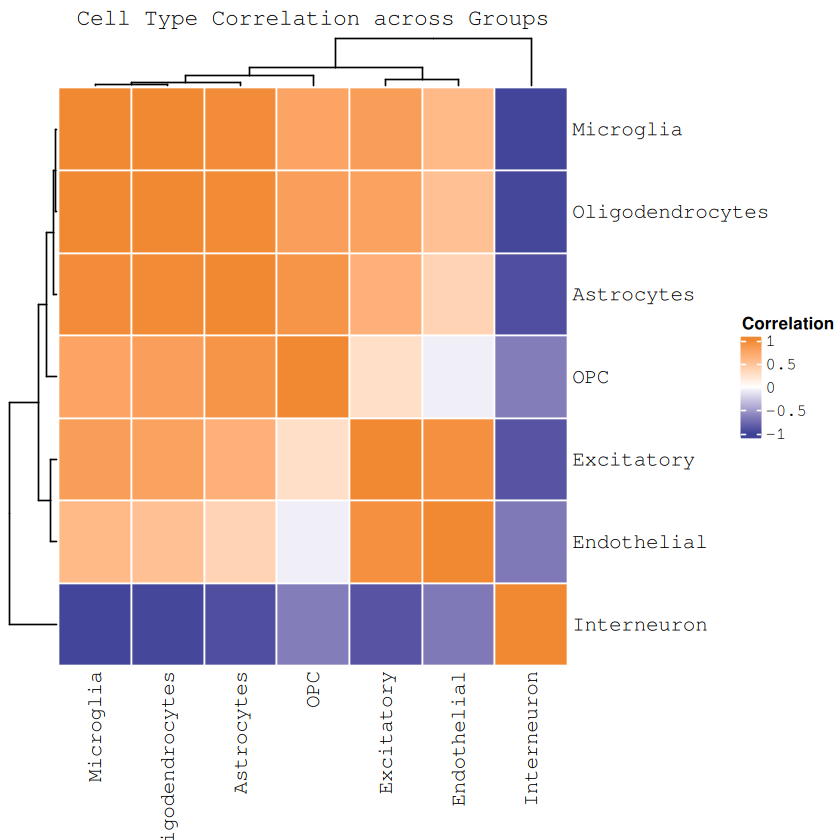

In [61]:
# 计算相关性矩阵（对列进行相关，也就是看细胞类型之间的相关性）
df.cor <- cor(prop_wide)

# 设置颜色映射（蓝-白-红）
col_fun <- colorRamp2(c(-1, 0, 1), c("#404398", "white", "#F18932"))

# 画图
Heatmap(df.cor, 
        name = "Correlation", 
        col = col_fun,
        rect_gp = gpar(col = "white", lwd = 1), # 加个白格子边框好看点
        column_title = "Cell Type Correlation across Groups")

In [65]:
table(prop_df$group)


Disease  Health Therapy 
      7       7       7 

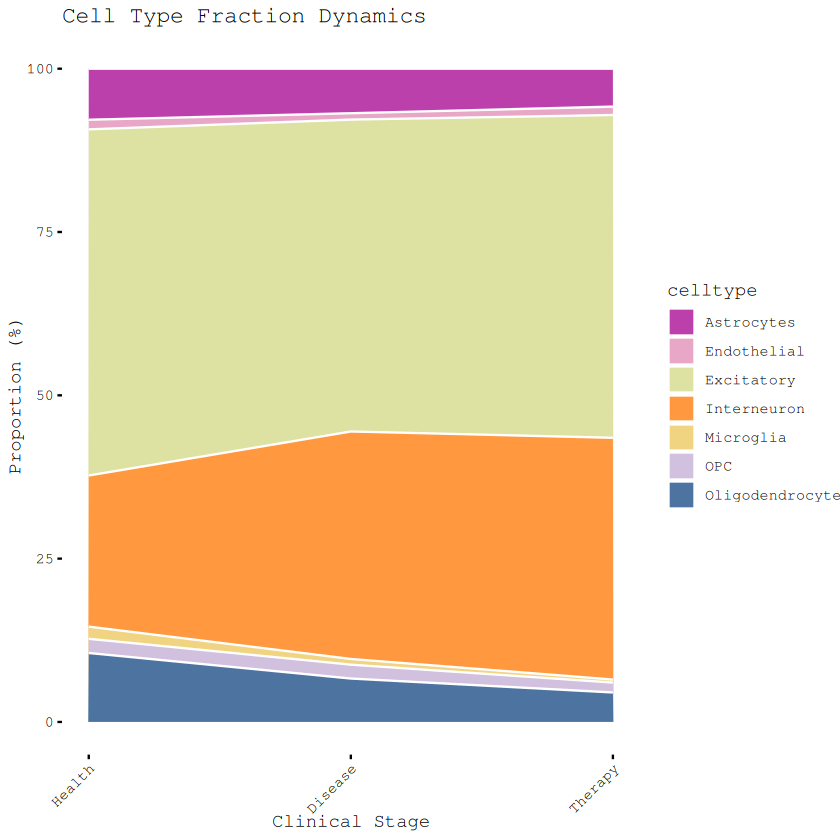

In [69]:
# 准备绘图数据
plot_data <- prop_df

# 【关键】处理 X 轴
# 如果你的分组是有顺序的（比如 I期, II期, III期），必须指定 Level 顺序
# 请手动修改下面的 levels = c(...) 确保顺序是对的
# 如果不指定，R 会按字母顺序排 (I, II, III 可能会乱)
plot_data$stage_factor <- factor(plot_data[[my_group]], 
                                 levels = c("Health", "Disease", "Therapy")) # 修改这里！

# 将 Factor 转为数字，因为 geom_area 需要连续的 x 轴
plot_data$stage_numeric <- as.numeric(plot_data$stage_factor)

# 画图
ggplot(plot_data, aes(x = stage_numeric, y = freq, fill = !!sym(my_celltype))) +
  geom_area(alpha = 0.8, size = 0.5, color = "white") + # alpha设置透明度，color设置分割线
  scale_x_continuous(breaks = 1:length(levels(plot_data$stage_factor)), 
                     labels = levels(plot_data$stage_factor)) + # 把X轴数字再变回文字标签
  scale_fill_manual(values = color) + # 你的颜色，如果不够需补充
  labs(x = "Clinical Stage", y = "Proportion (%)", title = "Cell Type Fraction Dynamics") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))+
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    axis.line = element_blank() # 如果想更像纯艺图，可以把原本黑色的坐标轴线去掉q
  ) -> p1
p1 # X轴标签斜着放防重叠

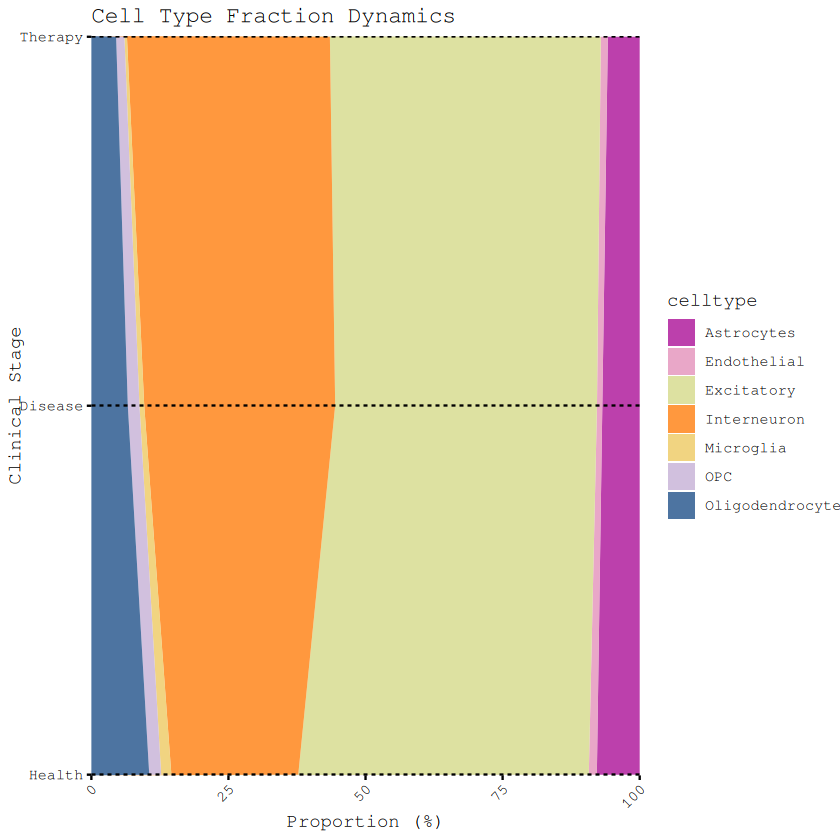

In [79]:
ggplot(plot_data, aes(x = stage_numeric, y = freq, fill = !!sym(my_celltype))) +
  # 1. 先画通过面积图
  geom_area(alpha = 0.8, size = 0.5, color = NA) + 
  
  # 2. 【关键修改】添加白色虚线
  # xintercept = unique(...) 意思是让线长在每一个 Stage 的刻度上
  geom_vline(xintercept = unique(plot_data$stage_numeric), 
             linetype = "dashed", 
             color = "black", 
             size = 0.5) +
  
  # 3. 设置轴和颜色
  scale_x_continuous(breaks = 1:length(levels(plot_data$stage_factor)), 
                     labels = levels(plot_data$stage_factor),
                     expand = c(0, 0)) + # expand=c(0,0) 让图的两边紧贴Y轴，不留白
  scale_y_continuous(expand = c(0, 0)) + # 让底部紧贴X轴
  
  scale_fill_manual(values = color) +
  
  labs(x = "Clinical Stage", y = "Proportion (%)", title = "Cell Type Fraction Dynamics") +
  theme_classic() +
  #+
  coord_flip()+
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    axis.line = element_blank() # 如果想更像纯艺图，可以把原本黑色的坐标轴线去掉q
  ) -> p1
p1

In [81]:
ggsave(p1,filename = '../figure/figure1/4.ratio.pdf',width = 8,height = 4)

In [74]:
library(scop)

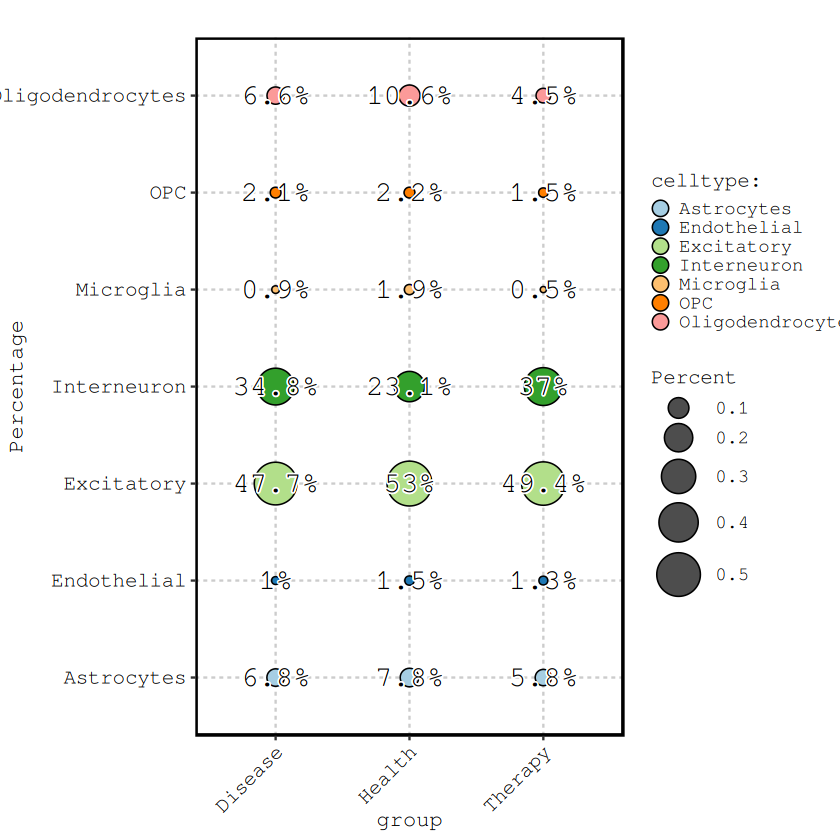

In [78]:
p1 = CellStatPlot(
  scRNA,
  stat.by = "celltype",
  group.by = "group",
  plot_type = "dot",
  label = T,
  label.size = 6
)
p1

In [82]:
library(Startrac)


Attaching package: ‘Startrac’


The following object is masked from ‘package:NMF’:

    plot


The following object is masked from ‘package:VGAM’:

    plot


The following object is masked from ‘package:stats4’:

    plot


The following object is masked from ‘package:graphics’:

    plot


The following object is masked from ‘package:base’:

    plot




In [83]:
# 取出注释信息：
data4roe <- scRNA@meta.data

# 计算Ro/e，实际计算速度与细胞数量关系不表达，算起来非常快：
Roe <-calTissueDist(data4roe,
byPatient = F,
colname.cluster ="celltype", # 不同细胞分群，为结果中Ro/e矩阵的“行名”
colname.patient ="sample", # 不同样本
colname.tissue ="group", # 不同Group，为结果中Ro/e矩阵的“列名”
method ="chisq", # 可选："chisq", "fisher", and "freq" 
min.rowSum =0) # 整行的和为0则忽略

# 看一下Ro/e的结果：  
Roe

                  
                     Disease    Health   Therapy
  Astrocytes       1.0099803 1.1575675 0.8596377
  Endothelial      0.7871251 1.1904211 1.0380143
  Excitatory       0.9561663 1.0611096 0.9895999
  Interneuron      1.0852661 0.7210726 1.1534510
  Microglia        0.8504813 1.8246695 0.4516204
  OPC              1.1090385 1.1323805 0.7891594
  Oligodendrocytes 0.9422512 1.4967248 0.6398665

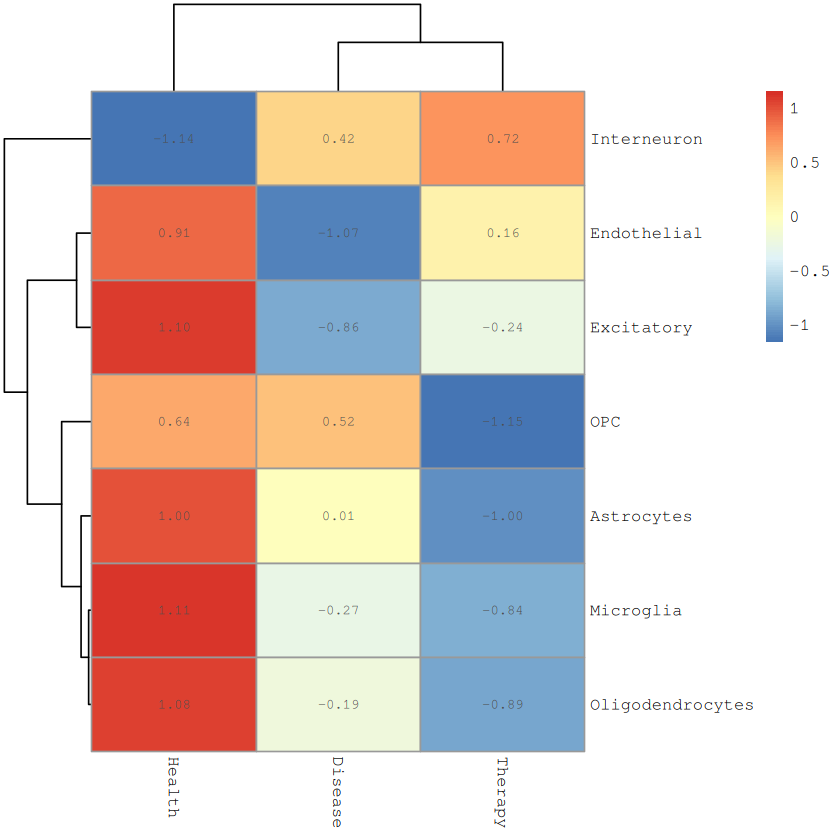

In [84]:
# 先来张最朴实无华的图：
pheatmap(Roe,display_numbers = T,scale ='row')

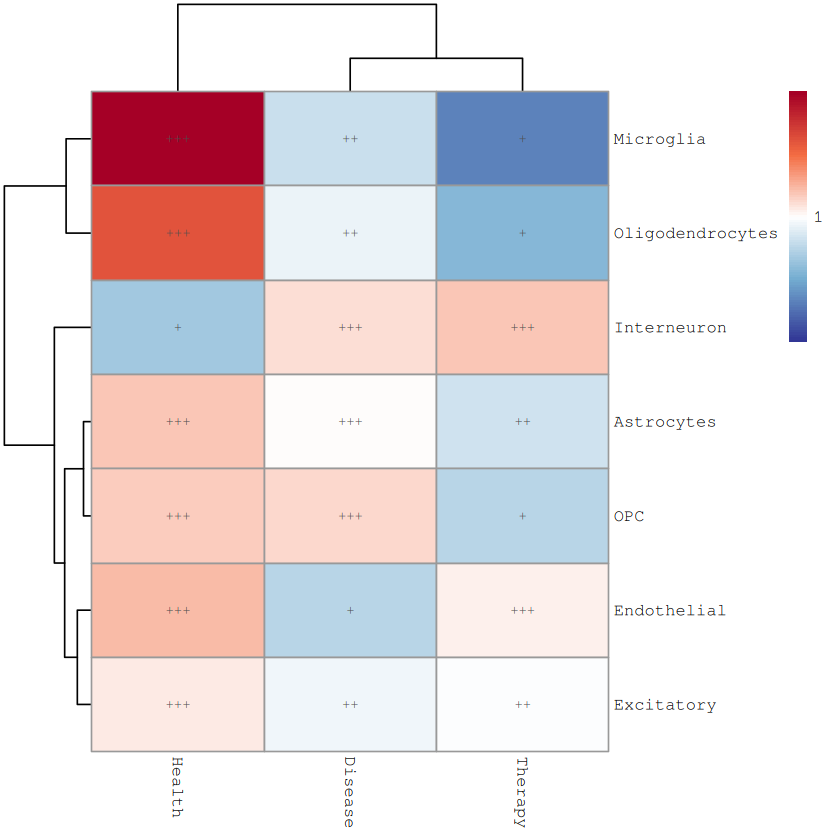

In [85]:
# 使用Biomamba祖传渐变色创建连续颜色梯度：
my_palette <-colorRampPalette(c("#313695", "#74ADD1", "#FFFFFF", "#F46D43", "#A50026"))(100)
# 设置以1为中心的对称断点
max_abs_deviation <-max(abs(Roe -1), na.rm =TRUE)
breaks <-seq(1- max_abs_deviation, 1+ max_abs_deviation, 
length.out =101)

#  定义Ro/e分级标准，生成与Roe同维度的标注矩阵（关键步骤）
# 根据Ro/e值替换为对应符号
anno_matrix <-ifelse(
  Roe >1, "+++",
ifelse(Roe >0.8& Roe <=1, "++",
ifelse(Roe >0.2& Roe <=0.8, "+",
ifelse(Roe >0& Roe <=0.2, "+/−", "−")))
)

# 显示加减号的热图：
pheatmap(Roe,
color = my_palette,
breaks = breaks,legend_breaks =c(-4,-2,0,1,2,4,6),#c(fivenum(Roe),1)
display_numbers = anno_matrix  # 传递标注矩阵，显示符号而非数值   
         )

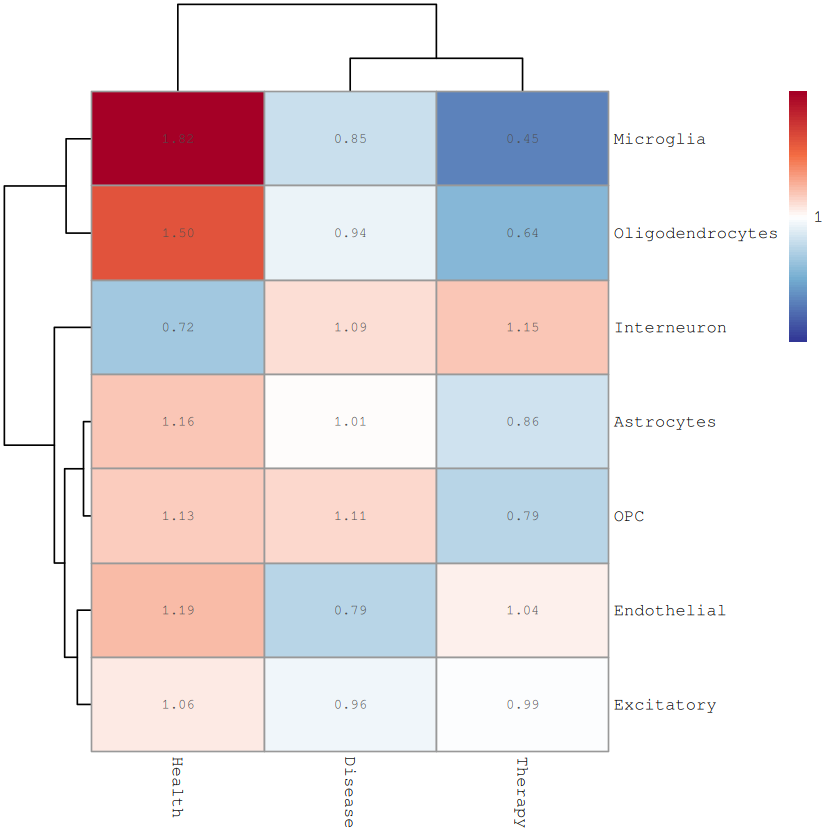

In [86]:
# 显示实际Ro/e score的热图：
pheatmap(Roe,
color = my_palette,
breaks = breaks,legend_breaks =c(-4,-2,0,1,2,4,6),#c(fivenum(Roe),1)
display_numbers = T  # 显示数值   
         )

In [88]:
dev.off()
pdf('../figure/figure1/4.roe.pdf',width = 7,height = 6)
pheatmap(Roe,
color = my_palette,
breaks = breaks,legend_breaks =c(-4,-2,0,1,2,4,6),#c(fivenum(Roe),1)
display_numbers = T  # 显示数值   
         )
dev.off()

pdf 
  3

pdf 
  3